# Isolation Forest Fraud Detection

## Company-Ready Experiment Notebook

This notebook presents the Isolation Forest experiment as a complete, reproducible modeling study for the PaySim fraud-detection project.

The notebook follows the actual experimental design already used in the project:

**Raw PaySim → feature engineering → controlled split → baseline → hyperparameter search → final model → threshold calibration → test evaluation → error analysis → deployment artifacts**

### Current experiment at a glance

| Item | Current setup |
|---|---|
| Dataset | PaySim |
| Rows loaded | 500,000 |
| Model | Isolation Forest |
| Final configuration | 500 trees, `max_samples=0.5`, `max_features=1.0` |
| Features | 19 |
| Train / Validation / Test | 60% / 20% / 20% |
| Training data for anomaly detector | Legitimate training transactions only |
| Threshold selection | Validation-set F1 maximization |
| Test set | Held out until final evaluation |

> The current experiment uses a 500,000-row subset rather than the complete PaySim dataset. The notebook therefore documents a controlled experiment, not a full-dataset training claim.

## Experiment map

```text
                         PaySim
                           |
                           v
                 Data quality checks
                           |
                           v
                 Feature engineering
                           |
                           v
              19 model-ready features
                           |
                           v
             Stratified train / val / test
                           |
              +------------+------------+
              |                         |
              v                         v
      Legitimate train only       Validation + Test
              |
              v
       Baseline Isolation Forest
              |
              v
      Hyperparameter search
              |
              v
    Select best validation setup
              |
              v
    Retrain final Isolation Forest
              |
              v
      Anomaly score generation
              |
              v
     Validation threshold search
              |
              v
        Freeze threshold
              |
              v
         Final test set
              |
              v
   Metrics + confusion matrix + errors
              |
              v
       Serialize model artifacts
```

In [4]:
# ============================================================
# 1. ENVIRONMENT
# ============================================================

import json
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    pass

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

print("Environment ready.")
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Scikit-learn:", __import__("sklearn").__version__)
print("Joblib      :", joblib.__version__)


Environment ready.
NumPy       : 2.2.6
Pandas      : 2.3.3
Scikit-learn: 1.7.2
Joblib      : 1.6.0


## 1. Experiment configuration

The configuration below is deliberately kept explicit so that the experiment can be reproduced and audited later.

In [5]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

possible_paths = [
    Path(r"D:\Real-Time-Financial-Fraud-Detection-Pipeline-\data\PS_20174392719_1491204439457_log.csv"),
    Path(r".\data\PS_20174392719_1491204439457_log.csv"),
    Path(r"..\data\PS_20174392719_1491204439457_log.csv"),
    Path.cwd() / "data" / "PS_20174392719_1491204439457_log.csv",
]

DATA_PATH = next((p for p in possible_paths if p.exists()), possible_paths[0])

MAX_ROWS = 500_000

RANDOM_STATE = 42

TEST_SIZE = 0.20
VALIDATION_SIZE = 0.25

# Final-model capacity
N_ESTIMATORS = 500
MAX_SAMPLES = 1.0
MAX_FEATURES = 1.0
CONTAMINATION = "auto"
BOOTSTRAP = False
N_JOBS = -1

# Threshold study
THRESHOLD_POINTS = 500
TARGET_RECALL = 0.95

# Controlled search sample
SEARCH_ROWS = 100_000

PROJECT_ROOT = Path(r"D:\Real-Time-Financial-Fraud-Detection-Pipeline-")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = DATA_PATH.parent.parent if DATA_PATH.exists() else Path.cwd()

MODEL_DIR = PROJECT_ROOT / "models"
RESULT_DIR = PROJECT_ROOT / "results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset       :", DATA_PATH.resolve())
print("Rows          :", f"{MAX_ROWS:,}")
print("Split         : 60% train / 20% validation / 20% test")
print("Search sample :", f"{SEARCH_ROWS:,}")
print("Target recall :", f"{TARGET_RECALL:.0%}")
print("Model Dir     :", MODEL_DIR.resolve())
print("Result Dir    :", RESULT_DIR.resolve())


Dataset       : D:\Real-Time-Financial-Fraud-Detection-Pipeline-\data\PS_20174392719_1491204439457_log.csv
Rows          : 500,000
Split         : 60% train / 20% validation / 20% test
Search sample : 100,000
Target recall : 95%
Model Dir     : D:\Real-Time-Financial-Fraud-Detection-Pipeline-\models
Result Dir    : D:\Real-Time-Financial-Fraud-Detection-Pipeline-\results


## 2. Load and inspect the raw data

The raw PaySim schema contains transaction type, amount, origin/destination balances, account identifiers, and fraud labels.

`isFraud` is treated as ground truth for evaluation and is not passed into the anomaly detector.

In [6]:
# ============================================================
# 3. LOAD PAYSIM
# ============================================================

if not DATA_PATH.exists():
    for p in [
        Path(r"D:\Real-Time-Financial-Fraud-Detection-Pipeline-\data\PS_20174392719_1491204439457_log.csv"),
        Path(r".\data\PS_20174392719_1491204439457_log.csv"),
        Path(r"..\data\PS_20174392719_1491204439457_log.csv"),
    ]:
        if p.exists():
            DATA_PATH = p
            break

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"PaySim file not found: {DATA_PATH.resolve()}\n"
        "Please ensure the CSV file is located inside the 'data' directory."
    )

start = time.perf_counter()

df = pd.read_csv(
    DATA_PATH,
    nrows=MAX_ROWS,
    low_memory=False
)

load_time = time.perf_counter() - start

print("Rows loaded :", f"{len(df):,}")
print("Columns     :", len(df.columns))
print("Load time   :", f"{load_time:.2f} sec")

print("\nRaw columns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

display(df.head())


Rows loaded : 500,000
Columns     : 11
Load time   : 0.69 sec

Raw columns:
01. step
02. type
03. amount
04. nameOrig
05. oldbalanceOrg
06. newbalanceOrig
07. nameDest
08. oldbalanceDest
09. newbalanceDest
10. isFraud
11. isFlaggedFraud


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
# ============================================================
# 4. DATA QUALITY
# ============================================================

quality = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str).values,
    "Missing": df.isna().sum().values,
    "Missing %": (
        df.isna().sum().values / len(df) * 100
    ).round(4),
})

display(quality)

print("Duplicate rows:", f"{df.duplicated().sum():,}")

fraud_counts = df["isFraud"].value_counts().sort_index()

display(
    pd.DataFrame({
        "Label": fraud_counts.index,
        "Meaning": [
            "Legitimate" if x == 0 else "Fraud"
            for x in fraud_counts.index
        ],
        "Count": fraud_counts.values,
        "Percentage": (
            fraud_counts.values / len(df) * 100
        ).round(4),
    })
)

print(
    f"Fraud rate: {df['isFraud'].mean() * 100:.4f}%"
)

,Column,Dtype,Missing,Missing %
0,step,int64,0,0.0
1,type,object,0,0.0
2,amount,float64,0,0.0
3,nameOrig,object,0,0.0
4,oldbalanceOrg,float64,0,0.0
5,newbalanceOrig,float64,0,0.0
6,nameDest,object,0,0.0
7,oldbalanceDest,float64,0,0.0
8,newbalanceDest,float64,0,0.0
9,isFraud,int64,0,0.0


Duplicate rows: 0


,Label,Meaning,Count,Percentage
0,0,Legitimate,499767,99.9534
1,1,Fraud,233,0.0466


Fraud rate: 0.0466%


## 3. Feature engineering

The feature layer converts raw transaction fields into behavioral signals that the Isolation Forest can process.

The transformation deliberately excludes:

- `isFraud`
- `isFlaggedFraud`
- `nameOrig`
- `nameDest`

The resulting model input contains 19 features.

In [8]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================

work = df.copy()

work["orig_balance_change"] = (
    work["oldbalanceOrg"] - work["newbalanceOrig"]
)

work["dest_balance_change"] = (
    work["newbalanceDest"] - work["oldbalanceDest"]
)

work["orig_balance_error"] = (
    work["amount"] - work["orig_balance_change"]
)

work["dest_balance_error"] = (
    work["amount"] - work["dest_balance_change"]
)

work["orig_zero_after"] = (
    work["newbalanceOrig"] == 0
).astype(int)

work["dest_zero_before"] = (
    work["oldbalanceDest"] == 0
).astype(int)

work["dest_zero_after"] = (
    work["newbalanceDest"] == 0
).astype(int)

work["log_amount"] = np.log1p(
    work["amount"]
)

work = pd.get_dummies(
    work,
    columns=["type"],
    prefix="type",
    dtype=int,
)

feature_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_change",
    "dest_balance_change",
    "orig_balance_error",
    "dest_balance_error",
    "orig_zero_after",
    "dest_zero_before",
    "dest_zero_after",
    "log_amount",
]

feature_columns += sorted(
    [
        col
        for col in work.columns
        if col.startswith("type_")
    ]
)

X = work[
    feature_columns
].astype(np.float32)

y = work[
    "isFraud"
].astype(int)

print("Rows     :", f"{len(X):,}")
print("Features :", X.shape[1])

print("\nFeature order:")
for i, feature in enumerate(feature_columns, start=1):
    print(f"{i:02d}. {feature}")

display(X.head())

Rows     : 500,000
Features : 19

Feature order:
01. step
02. amount
03. oldbalanceOrg
04. newbalanceOrig
05. oldbalanceDest
06. newbalanceDest
07. orig_balance_change
08. dest_balance_change
09. orig_balance_error
10. dest_balance_error
11. orig_zero_after
12. dest_zero_before
13. dest_zero_after
14. log_amount
15. type_CASH_IN
16. type_CASH_OUT
17. type_DEBIT
18. type_PAYMENT
19. type_TRANSFER


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_change,dest_balance_change,orig_balance_error,dest_balance_error,orig_zero_after,dest_zero_before,dest_zero_after,log_amount,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1.0,9839.639648,170136.0,160296.359375,0.0,0.0,9839.639648,0.0,-1.455192e-11,9839.639648,0.0,1.0,1.0,9.194276,0.0,0.0,0.0,1.0,0.0
1,1.0,1864.280029,21249.0,19384.720703,0.0,0.0,1864.280029,0.0,1.136868e-12,1864.280029,0.0,1.0,1.0,7.531167,0.0,0.0,0.0,1.0,0.0
2,1.0,181.000000,181.0,0.000000,0.0,0.0,181.000000,0.0,0.000000e+00,181.000000,1.0,1.0,1.0,5.204007,0.0,0.0,0.0,0.0,1.0
3,1.0,181.000000,181.0,0.000000,21182.0,0.0,181.000000,-21182.0,0.000000e+00,21363.000000,1.0,0.0,1.0,5.204007,0.0,1.0,0.0,0.0,0.0
4,1.0,11668.139648,41554.0,29885.859375,0.0,0.0,11668.139648,0.0,0.000000e+00,11668.139648,0.0,1.0,1.0,9.364703,0.0,0.0,0.0,1.0,0.0


In [9]:
# ============================================================
# 6. FEATURE CONTRACT CHECK
# ============================================================

forbidden = [
    "isFraud",
    "isFlaggedFraud",
    "nameOrig",
    "nameDest",
]

found = [
    col
    for col in forbidden
    if col in X.columns
]

if found:
    raise ValueError(
        f"Forbidden columns found in model input: {found}"
    )

nan_count = int(X.isna().sum().sum())

inf_count = int(
    np.isinf(
        X.to_numpy()
    ).sum()
)

print("Forbidden model-input columns: PASS")
print("NaN values                   :", nan_count)
print("Infinite values              :", inf_count)

if nan_count or inf_count:
    raise ValueError(
        "Feature matrix contains NaN or infinite values."
    )

Forbidden model-input columns: PASS
NaN values                   : 0
Infinite values              : 0


## 4. Train / validation / test design

The dataset is stratified into three partitions. Isolation Forest is trained only on legitimate transactions from the training split.

```text
                     500,000 rows
                          |
                 stratified split
                          |
              +-----------+-----------+
              |                       |
            80%                      20%
              |                       |
        Train + Validation           Test
              |
        stratified split
              |
        +-----+-----+
        |           |
      60%          20%
     Train      Validation
        |
        v
Legitimate rows only
```

The held-out test set remains untouched until final evaluation.

In [10]:
# ============================================================
# 7. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp,
    y_train_temp,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_temp,
)

rows = []

for name, labels in [
    ("Training", y_train),
    ("Validation", y_val),
    ("Test", y_test),
]:
    rows.append({
        "Dataset": name,
        "Rows": len(labels),
        "Legitimate": int((labels == 0).sum()),
        "Fraud": int((labels == 1).sum()),
        "Fraud %": round(labels.mean() * 100, 4),
    })

display(pd.DataFrame(rows))

normal_mask = y_train == 0

X_train_normal = X_train.loc[
    normal_mask
].copy()

assert int(
    y_train.loc[normal_mask].sum()
) == 0

print(
    "\nNormal-only training rows:",
    f"{len(X_train_normal):,}"
)

print(
    "Fraud labels entering Isolation Forest training: 0"
)

,Dataset,Rows,Legitimate,Fraud,Fraud %
0,Training,300000,299860,140,0.0467
1,Validation,100000,99954,46,0.0460
2,Test,100000,99953,47,0.0470



Normal-only training rows: 299,860
Fraud labels entering Isolation Forest training: 0


## 5. Baseline model

The baseline provides a reference point before changing the main Isolation Forest parameters.

It uses 200 trees with the default sample strategy and all features.

In [11]:
# ============================================================
# 8. BASELINE MODEL
# ============================================================

baseline_model = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    max_features=1.0,
    contamination="auto",
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

start = time.perf_counter()

baseline_model.fit(
    X_train_normal
)

baseline_time = (
    time.perf_counter()
    - start
)

print("Baseline model trained.")
print("Trees        :", 200)
print("Training time:", f"{baseline_time:.2f} sec")

Baseline model trained.
Trees        : 200
Training time: 0.62 sec


## 6. Hyperparameter search

Five controlled configurations are compared.

The search uses a reproducible 100,000-row subset of the legitimate training data to reduce repeated training cost. After selecting the configuration, the final model is retrained on the full legitimate training set.

The three parameters under study are:

- `n_estimators` — number of isolation trees
- `max_samples` — sample fraction available to each tree
- `max_features` — feature fraction available to each tree

In [12]:
# ============================================================
# 9. SEARCH SETUP
# ============================================================

search_size = min(
    SEARCH_ROWS,
    len(X_train_normal)
)

rng = np.random.RandomState(
    RANDOM_STATE
)

positions = rng.choice(
    len(X_train_normal),
    size=search_size,
    replace=False,
)

X_search_train = X_train_normal.iloc[
    positions
].copy()

search_configs = [
    {
        "name": "IF_200_auto",
        "n_estimators": 200,
        "max_samples": "auto",
        "max_features": 1.0,
    },
    {
        "name": "IF_500_auto",
        "n_estimators": 500,
        "max_samples": "auto",
        "max_features": 1.0,
    },
    {
        "name": "IF_500_half_features",
        "n_estimators": 500,
        "max_samples": "auto",
        "max_features": 0.5,
    },
    {
        "name": "IF_500_half_samples",
        "n_estimators": 500,
        "max_samples": 0.5,
        "max_features": 1.0,
    },
    {
        "name": "IF_800_half_features",
        "n_estimators": 800,
        "max_samples": "auto",
        "max_features": 0.5,
    },
]

print(
    "Normal training rows available:",
    f"{len(X_train_normal):,}",
)

print(
    "Rows used during search:",
    f"{len(X_search_train):,}",
)

display(
    pd.DataFrame(search_configs)
)

Normal training rows available: 299,860
Rows used during search: 100,000


,name,n_estimators,max_samples,max_features
0,IF_200_auto,200,auto,1.0
1,IF_500_auto,500,auto,1.0
2,IF_500_half_features,500,auto,0.5
3,IF_500_half_samples,500,0.5,1.0
4,IF_800_half_features,800,auto,0.5


In [13]:
# ============================================================
# 10. HYPERPARAMETER SEARCH
# ============================================================

search_results = []

for cfg in search_configs:

    model = IsolationForest(
        n_estimators=cfg["n_estimators"],
        max_samples=cfg["max_samples"],
        max_features=cfg["max_features"],
        contamination="auto",
        bootstrap=False,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )

    start = time.perf_counter()

    model.fit(
        X_search_train
    )

    train_time = (
        time.perf_counter()
        - start
    )

    val_score = -model.decision_function(
        X_val
    )

    candidates = np.unique(
        np.percentile(
            val_score,
            np.linspace(90, 99.9, 200),
        )
    )

    best = None

    for threshold in candidates:

        pred = (
            val_score >= threshold
        ).astype(int)

        p = precision_score(
            y_val,
            pred,
            zero_division=0,
        )

        r = recall_score(
            y_val,
            pred,
            zero_division=0,
        )

        f = f1_score(
            y_val,
            pred,
            zero_division=0,
        )

        if (
            best is None
            or f > best["f1"]
        ):
            best = {
                "threshold": float(threshold),
                "precision": float(p),
                "recall": float(r),
                "f1": float(f),
            }

    search_results.append({
        **cfg,
        "training_time_seconds": train_time,
        "validation_precision": best["precision"],
        "validation_recall": best["recall"],
        "validation_f1": best["f1"],
        "validation_threshold": best["threshold"],
    })

    print(
        f"{cfg['name']:26s} | "
        f"F1={best['f1']:.4f} | "
        f"Recall={best['recall']:.4f} | "
        f"Precision={best['precision']:.4f} | "
        f"Time={train_time:.2f}s"
    )

search_results_df = pd.DataFrame(
    search_results
)

search_results_df = search_results_df.sort_values(
    "validation_f1",
    ascending=False,
).reset_index(drop=True)

print("\nSearch results:")
display(search_results_df)

IF_200_auto                | F1=0.0522 | Recall=0.1957 | Precision=0.0301 | Time=0.41s
IF_500_auto                | F1=0.0650 | Recall=0.1739 | Precision=0.0400 | Time=1.00s
IF_500_half_features       | F1=0.0522 | Recall=0.1957 | Precision=0.0301 | Time=1.22s
IF_500_half_samples        | F1=0.2055 | Recall=0.3261 | Precision=0.1500 | Time=2.59s
IF_800_half_features       | F1=0.0541 | Recall=0.1739 | Precision=0.0320 | Time=1.86s

Search results:


,name,n_estimators,max_samples,max_features,training_time_seconds,validation_precision,validation_recall,validation_f1,validation_threshold
0,IF_500_half_samples,500,0.5,1.0,2.591073,0.1500,0.326087,0.205479,0.124634
1,IF_500_auto,500,auto,1.0,1.002938,0.0400,0.173913,0.065041,0.150216
2,IF_800_half_features,800,auto,0.5,1.861901,0.0320,0.173913,0.054054,0.138388
3,IF_200_auto,200,auto,1.0,0.413561,0.0301,0.195652,0.052174,0.140717
4,IF_500_half_features,500,auto,0.5,1.221464,0.0301,0.195652,0.052174,0.132175


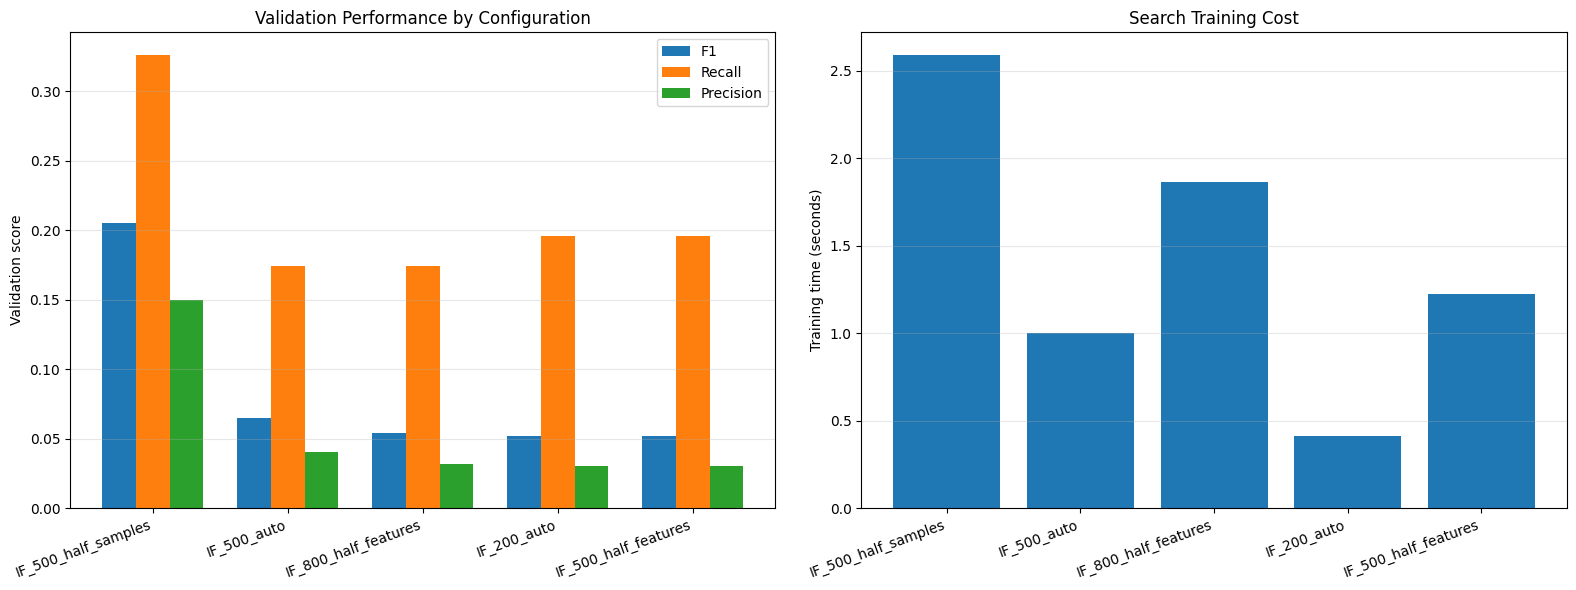

In [14]:
# ============================================================
# 11. SEARCH RESULT VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

x = np.arange(
    len(search_results_df)
)

width = 0.25

axes[0].bar(
    x - width,
    search_results_df["validation_f1"],
    width,
    label="F1",
)

axes[0].bar(
    x,
    search_results_df["validation_recall"],
    width,
    label="Recall",
)

axes[0].bar(
    x + width,
    search_results_df["validation_precision"],
    width,
    label="Precision",
)

axes[0].set_xticks(
    x,
    search_results_df["name"],
    rotation=20,
    ha="right",
)

axes[0].set_ylabel(
    "Validation score"
)

axes[0].set_title(
    "Validation Performance by Configuration"
)

axes[0].legend()
axes[0].grid(
    axis="y",
    alpha=0.3
)

axes[1].bar(
    search_results_df["name"],
    search_results_df["training_time_seconds"],
)

axes[1].set_xticklabels(
    search_results_df["name"],
    rotation=20,
    ha="right",
)

axes[1].set_ylabel(
    "Training time (seconds)"
)

axes[1].set_title(
    "Search Training Cost"
)

axes[1].grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Search result

The current search identifies:

```text
IF_500_half_samples
500 trees
max_samples = 0.5
max_features = 1.0
```

as the strongest configuration among the five candidates when the comparison is based on the highest validation F1.

Its validation result was:

- Precision: **0.1500**
- Recall: **0.3261**
- F1: **0.2055**

This is a relative result within the configurations tested; it should not be described as an absolute claim that the score is "high".

In [15]:
# ============================================================
# 12. SELECT BEST CONFIGURATION
# ============================================================

best_config_row = (
    search_results_df
    .sort_values(
        "validation_f1",
        ascending=False,
    )
    .iloc[0]
)

BEST_CONFIG_NAME = (
    best_config_row["name"]
)

selected_config = next(
    cfg
    for cfg in search_configs
    if cfg["name"] == BEST_CONFIG_NAME
)

print(
    "Selected configuration:",
    BEST_CONFIG_NAME
)

display(
    pd.DataFrame([selected_config])
)

print(
    "Validation Precision:",
    f"{best_config_row['validation_precision']:.4f}"
)

print(
    "Validation Recall   :",
    f"{best_config_row['validation_recall']:.4f}"
)

print(
    "Validation F1       :",
    f"{best_config_row['validation_f1']:.4f}"
)

Selected configuration: IF_500_half_samples


,name,n_estimators,max_samples,max_features
0,IF_500_half_samples,500,0.5,1.0


Validation Precision: 0.1500
Validation Recall   : 0.3261
Validation F1       : 0.2055


## 7. Final model training

The selected configuration is now retrained on **all legitimate transactions in the training partition**, rather than the smaller 100,000-row search subset.

This keeps hyperparameter search and final model training separate.

In [16]:
# ============================================================
# 13. FINAL ISOLATION FOREST
# ============================================================

final_model = IsolationForest(
    n_estimators=selected_config["n_estimators"],
    max_samples=selected_config["max_samples"],
    max_features=selected_config["max_features"],
    contamination="auto",
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

start = time.perf_counter()

final_model.fit(
    X_train_normal
)

final_training_time = (
    time.perf_counter()
    - start
)

print("Final model trained.")
print("Trees        :", selected_config["n_estimators"])
print("Max samples  :", selected_config["max_samples"])
print("Max features :", selected_config["max_features"])
print(
    "Training time:",
    f"{final_training_time:.2f} sec"
)

Final model trained.
Trees        : 500
Max samples  : 0.5
Max features : 1.0
Training time: 10.64 sec


## 8. Anomaly score generation

Isolation Forest produces a continuous score rather than a final fraud label.

This experiment reverses the sign of `decision_function` so that:

```text
higher score → more anomalous
lower score  → more normal-like
```

The validation scores are used for threshold selection. The test scores are held for final evaluation.

In [17]:
# ============================================================
# 14. VALIDATION AND TEST ANOMALY SCORES
# ============================================================

start = time.perf_counter()

val_scores = (
    -final_model.decision_function(X_val)
)

val_inference_time = (
    time.perf_counter()
    - start
)

start = time.perf_counter()

test_scores = (
    -final_model.decision_function(X_test)
)

test_inference_time = (
    time.perf_counter()
    - start
)

print(
    "Validation inference:",
    f"{val_inference_time:.4f} sec"
)

print(
    "Test inference:",
    f"{test_inference_time:.4f} sec"
)

print("\nValidation score statistics:")
display(
    pd.Series(
        val_scores,
        name="validation_anomaly_score",
    ).describe().to_frame()
)

print("Test score statistics:")
display(
    pd.Series(
        test_scores,
        name="test_anomaly_score",
    ).describe().to_frame()
)

Validation inference: 3.9266 sec
Test inference: 3.8252 sec

Validation score statistics:


,validation_anomaly_score
count,100000.000000
mean,-0.111124
std,0.035794
min,-0.161575
25%,-0.133720
50%,-0.118193
75%,-0.096894
max,0.271406


Test score statistics:


,test_anomaly_score
count,100000.000000
mean,-0.110950
std,0.035919
min,-0.161568
25%,-0.133776
50%,-0.118201
75%,-0.096595
max,0.269736


## 9. Threshold calibration

The anomaly score is continuous, so we need an operating threshold to turn it into a fraud-alert decision.

The threshold is chosen **using the validation set**.

For each candidate threshold:

```text
anomaly score >= threshold
        ↓
potential fraud

anomaly score < threshold
        ↓
normal
```

Precision, recall, F1, false positives, and false negatives are then calculated.

The current primary threshold-selection rule is **maximum validation F1**.

In [18]:
# ============================================================
# 15. VALIDATION THRESHOLD SEARCH
# ============================================================

threshold_candidates = np.unique(
    np.percentile(
        val_scores,
        np.linspace(
            90,
            99.9,
            THRESHOLD_POINTS,
        ),
    )
)

threshold_results = []

for threshold in threshold_candidates:

    pred = (
        val_scores >= threshold
    ).astype(int)

    p = precision_score(
        y_val,
        pred,
        zero_division=0,
    )

    r = recall_score(
        y_val,
        pred,
        zero_division=0,
    )

    f = f1_score(
        y_val,
        pred,
        zero_division=0,
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        pred,
        labels=[0, 1],
    ).ravel()

    threshold_results.append({
        "threshold": float(threshold),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "true_negatives": int(tn),
    })

threshold_df = pd.DataFrame(
    threshold_results
)

best_f1_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_f1_threshold = float(
    best_f1_row["threshold"]
)

high_recall = threshold_df[
    threshold_df["recall"] >= TARGET_RECALL
].copy()

if len(high_recall) > 0:

    high_recall_row = (
        high_recall
        .sort_values(
            ["precision", "threshold"],
            ascending=[False, False],
        )
        .iloc[0]
    )

    high_recall_threshold = float(
        high_recall_row["threshold"]
    )

else:

    high_recall_row = None
    high_recall_threshold = None

print(
    "Best F1 threshold:",
    f"{best_f1_threshold:.8f}"
)

print(
    f"Precision={best_f1_row['precision']:.4f} | "
    f"Recall={best_f1_row['recall']:.4f} | "
    f"F1={best_f1_row['f1']:.4f}"
)

print()

if high_recall_row is not None:

    print(
        f"{TARGET_RECALL:.0%} recall threshold:",
        f"{high_recall_threshold:.8f}"
    )

    print(
        f"Precision={high_recall_row['precision']:.4f} | "
        f"Recall={high_recall_row['recall']:.4f} | "
        f"F1={high_recall_row['f1']:.4f}"
    )

else:

    print(
        f"No threshold candidate achieved "
        f"{TARGET_RECALL:.0%} validation recall."
    )

print("\nTop thresholds:")
display(
    threshold_df
    .sort_values("f1", ascending=False)
    .head(15)
)

Best F1 threshold: 0.10719670
Precision=0.1700 | Recall=0.3696 | F1=0.2329

No threshold candidate achieved 95% validation recall.

Top thresholds:


,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives
499,0.107197,0.170000,0.369565,0.232877,83,29,17,99871
498,0.100585,0.158333,0.413043,0.228916,101,27,19,99853
497,0.095107,0.150000,0.456522,0.225806,119,25,21,99835
496,0.089434,0.131250,0.456522,0.203883,139,25,21,99815
495,0.085664,0.127778,0.500000,0.203540,157,23,23,99797
494,0.081806,0.115000,0.500000,0.186992,177,23,23,99777
493,0.078325,0.109091,0.521739,0.180451,196,22,24,99758
492,0.073380,0.104603,0.543478,0.175439,214,21,25,99740
491,0.069647,0.096525,0.543478,0.163934,234,21,25,99720
490,0.067797,0.089606,0.543478,0.153846,254,21,25,99700


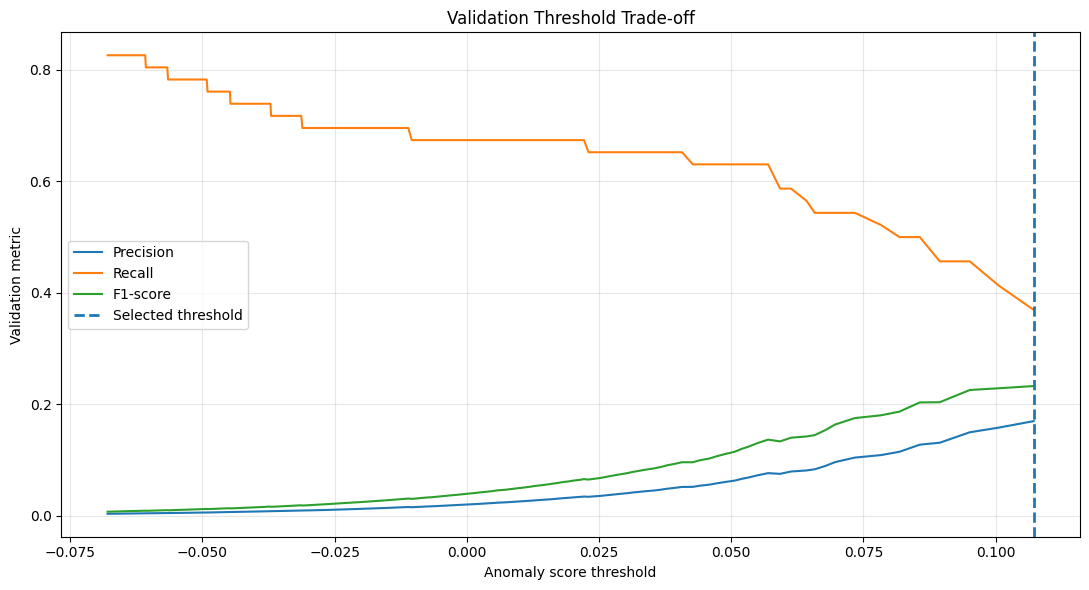

In [19]:
# ============================================================
# 16. THRESHOLD CURVES
# ============================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="F1-score"
)

plt.axvline(
    best_f1_threshold,
    linestyle="--",
    linewidth=2,
    label="Selected threshold"
)

if high_recall_threshold is not None:

    plt.axvline(
        high_recall_threshold,
        linestyle=":",
        linewidth=2,
        label="High-recall threshold"
    )

plt.xlabel(
    "Anomaly score threshold"
)

plt.ylabel(
    "Validation metric"
)

plt.title(
    "Validation Threshold Trade-off"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Threshold interpretation

The threshold is **not a probability of fraud**.

It is simply the cutoff applied to the model's anomaly-score scale.

For the current experiment:

```text
score < 0.10719670  → Normal
score ≥ 0.10719670  → Potential fraud
```

The high-recall study is also retained because this project places substantial importance on missed fraud.

In the current validation search, no candidate reached the configured 95% recall target.

## 10. Final evaluation on the untouched test set

Only after the model and threshold are fixed do we calculate the final test metrics.

This is the point at which `isFraud` is used to quantify:

- true positives
- true negatives
- false positives
- false negatives
- precision
- recall
- F1
- PR-AUC
- ROC-AUC
- false-positive rate
- false-negative rate

In [20]:
# ============================================================
# 17. FINAL TEST EVALUATION
# ============================================================

FINAL_THRESHOLD = best_f1_threshold

test_predictions = (
    test_scores >= FINAL_THRESHOLD
).astype(int)

precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0,
)

recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0,
)

f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0,
)

roc_auc = roc_auc_score(
    y_test,
    test_scores,
)

pr_auc = average_precision_score(
    y_test,
    test_scores,
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1],
).ravel()

false_positive_rate = (
    fp / (fp + tn)
    if (fp + tn)
    else 0
)

false_negative_rate = (
    fn / (fn + tp)
    if (fn + tp)
    else 0
)

print("Selected threshold:", f"{FINAL_THRESHOLD:.8f}")

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print()
print(
    f"TN={tn:,} | FP={fp:,} | "
    f"FN={fn:,} | TP={tp:,}"
)

print(
    "False positive rate:",
    f"{false_positive_rate:.4%}"
)

print(
    "False negative rate:",
    f"{false_negative_rate:.4%}"
)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Legitimate",
            "Fraud",
        ],
        digits=4,
        zero_division=0,
    )
)

Selected threshold: 0.10719670
Precision : 0.1485
Recall    : 0.3191
F1-score  : 0.2027
PR-AUC    : 0.1950
ROC-AUC   : 0.8569

TN=99,867 | FP=86 | FN=32 | TP=15
False positive rate: 0.0860%
False negative rate: 68.0851%

Classification report:
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9991    0.9994     99953
       Fraud     0.1485    0.3191    0.2027        47

    accuracy                         0.9988    100000
   macro avg     0.5741    0.6591    0.6011    100000
weighted avg     0.9993    0.9988    0.9990    100000



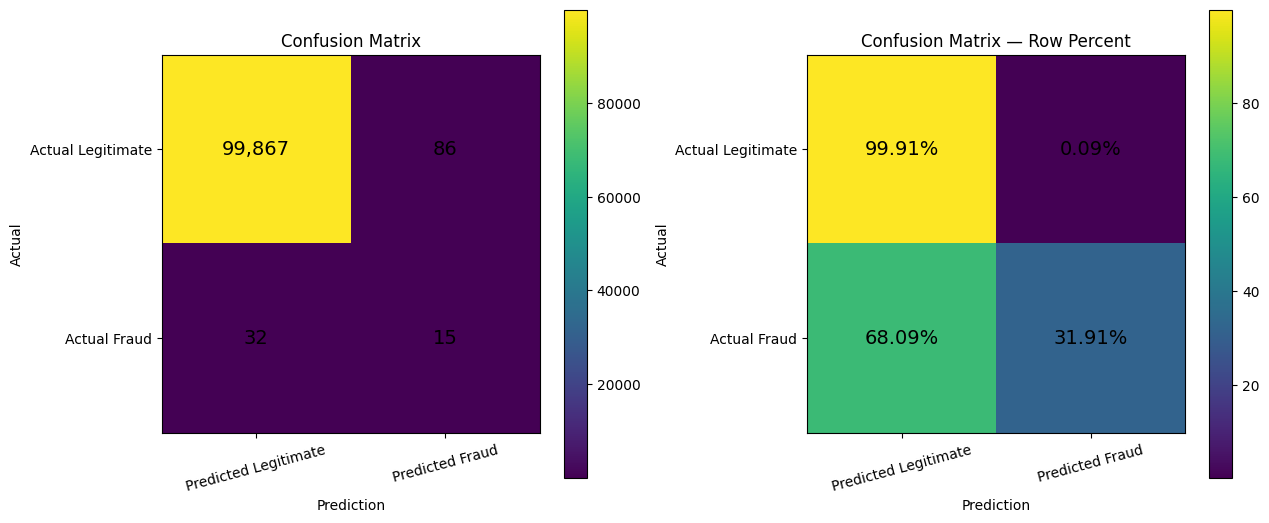

In [21]:
# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = np.array([
    [tn, fp],
    [fn, tp],
])

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5)
)

axes[0].imshow(cm)

axes[0].set_xticks(
    [0, 1],
    ["Predicted Legitimate", "Predicted Fraud"],
    rotation=15,
)

axes[0].set_yticks(
    [0, 1],
    ["Actual Legitimate", "Actual Fraud"],
)

for i in range(2):
    for j in range(2):
        axes[0].text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=14,
        )

axes[0].set_xlabel("Prediction")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix")
fig.colorbar(
    axes[0].images[0],
    ax=axes[0],
)

row_totals = cm.sum(axis=1, keepdims=True)
cm_pct = cm / row_totals * 100

axes[1].imshow(cm_pct)

axes[1].set_xticks(
    [0, 1],
    ["Predicted Legitimate", "Predicted Fraud"],
    rotation=15,
)

axes[1].set_yticks(
    [0, 1],
    ["Actual Legitimate", "Actual Fraud"],
)

for i in range(2):
    for j in range(2):
        axes[1].text(
            j,
            i,
            f"{cm_pct[i, j]:.2f}%",
            ha="center",
            va="center",
            fontsize=14,
        )

axes[1].set_xlabel("Prediction")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix — Row Percent")

fig.colorbar(
    axes[1].images[0],
    ax=axes[1],
)

plt.tight_layout()
plt.show()

### False-negative view

For fraud detection, the bottom-left cell is especially important:

```text
Actual Fraud
     +
Predicted Legitimate
     =
False Negative
```

In the current test experiment:

```text
False Negatives = 32
False Negative Rate = 68.09%
```

So the model is still missing a substantial portion of fraud cases at the F1-selected operating point. This is a central limitation to report rather than hide.

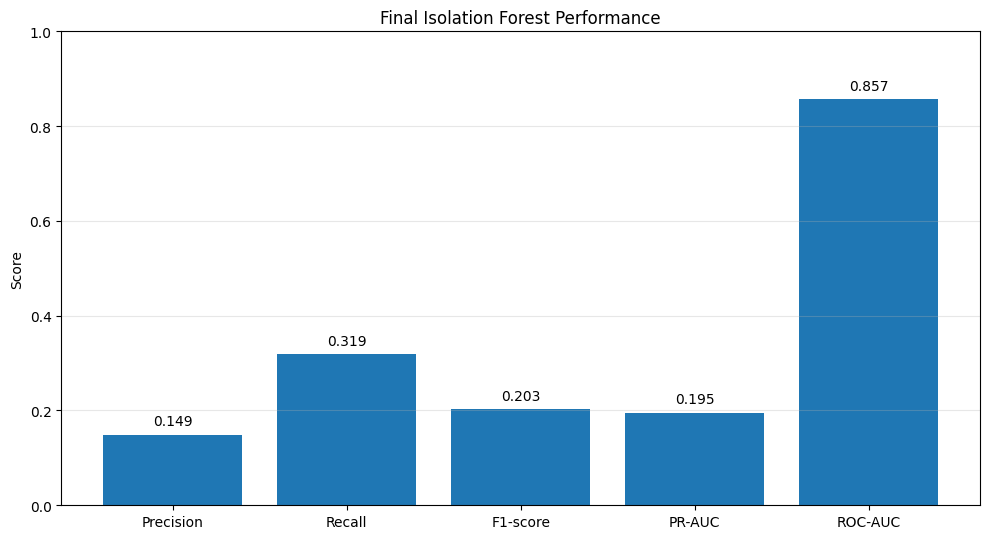

In [22]:
# ============================================================
# 19. FINAL METRIC BAR CHART
# ============================================================

final_metric_names = [
    "Precision",
    "Recall",
    "F1-score",
    "PR-AUC",
    "ROC-AUC",
]

final_metric_values = [
    precision,
    recall,
    f1,
    pr_auc,
    roc_auc,
]

plt.figure(
    figsize=(10, 5.5)
)

plt.bar(
    final_metric_names,
    final_metric_values,
)

plt.ylim(
    0,
    1
)

plt.ylabel(
    "Score"
)

plt.title(
    "Final Isolation Forest Performance"
)

for i, value in enumerate(
    final_metric_values
):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

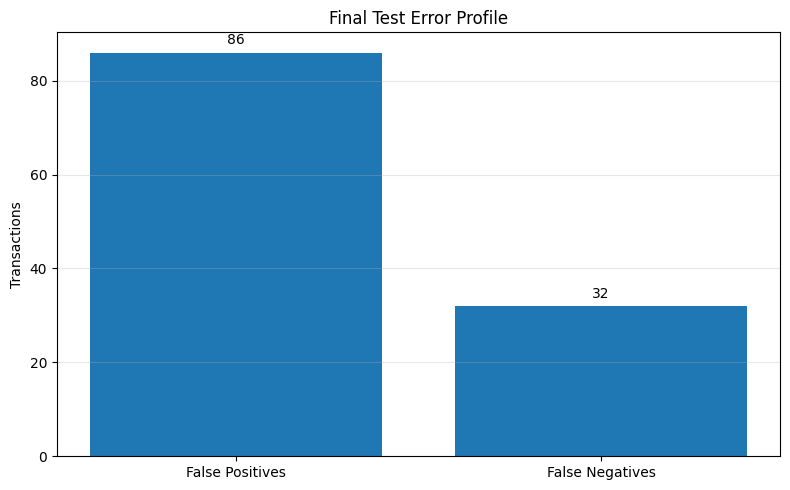

,Metric,Value
0,False Positive Rate,0.000860
1,False Negative Rate,0.680851


In [23]:
# ============================================================
# 20. ERROR PROFILE
# ============================================================

error_table = pd.DataFrame({
    "Error type": [
        "False Positives",
        "False Negatives",
    ],
    "Count": [
        fp,
        fn,
    ],
})

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    error_table["Error type"],
    error_table["Count"],
)

plt.ylabel(
    "Transactions"
)

plt.title(
    "Final Test Error Profile"
)

for i, value in enumerate(
    error_table["Count"]
):
    plt.text(
        i,
        value + max(error_table["Count"]) * 0.02,
        f"{value:,}",
        ha="center",
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

display(
    pd.DataFrame({
        "Metric": [
            "False Positive Rate",
            "False Negative Rate",
        ],
        "Value": [
            false_positive_rate,
            false_negative_rate,
        ],
    })
)

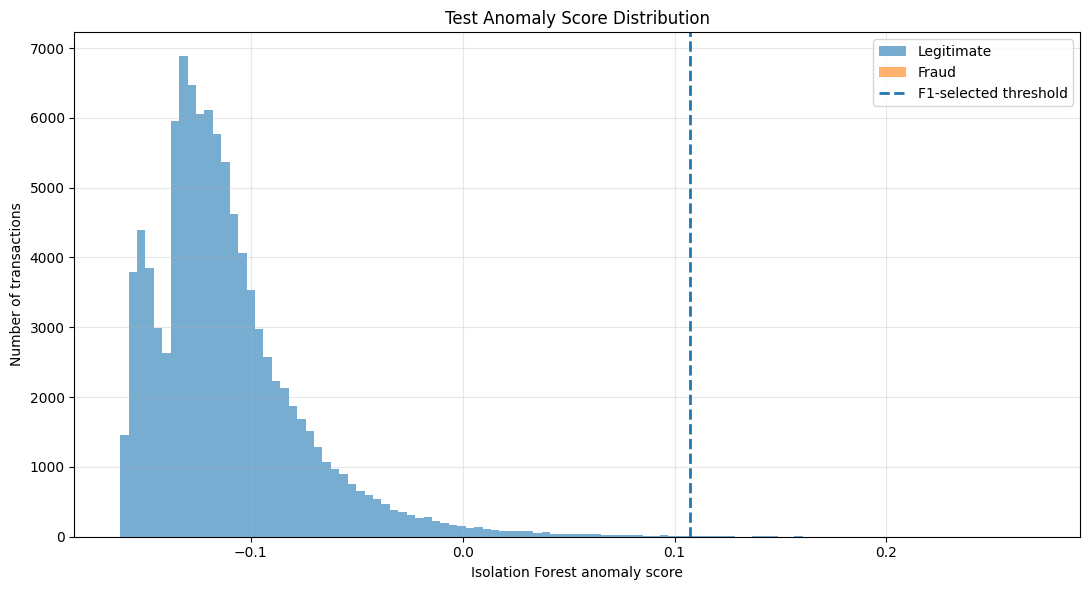

Legitimate score summary:


,legitimate
count,99953.000000
mean,-0.111023
std,0.035666
min,-0.161568
25%,-0.133778
50%,-0.118209
75%,-0.096641
max,0.236067


Fraud score summary:


,fraud
count,47.000000
mean,0.043598
std,0.127309
min,-0.156362
25%,-0.065100
50%,0.052488
75%,0.145354
max,0.269736


In [24]:
# ============================================================
# 21. SCORE DISTRIBUTION
# ============================================================

legitimate_scores = test_scores[
    y_test.to_numpy() == 0
]

fraud_scores = test_scores[
    y_test.to_numpy() == 1
]

plt.figure(
    figsize=(11, 6)
)

plt.hist(
    legitimate_scores,
    bins=100,
    alpha=0.60,
    label="Legitimate",
)

plt.hist(
    fraud_scores,
    bins=100,
    alpha=0.60,
    label="Fraud",
)

plt.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label="F1-selected threshold",
)

if high_recall_threshold is not None:

    plt.axvline(
        high_recall_threshold,
        linestyle=":",
        linewidth=2,
        label="High-recall threshold",
    )

plt.xlabel(
    "Isolation Forest anomaly score"
)

plt.ylabel(
    "Number of transactions"
)

plt.title(
    "Test Anomaly Score Distribution"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("Legitimate score summary:")
display(
    pd.Series(
        legitimate_scores
    ).describe().to_frame("legitimate")
)

print("Fraud score summary:")
display(
    pd.Series(
        fraud_scores
    ).describe().to_frame("fraud")
)

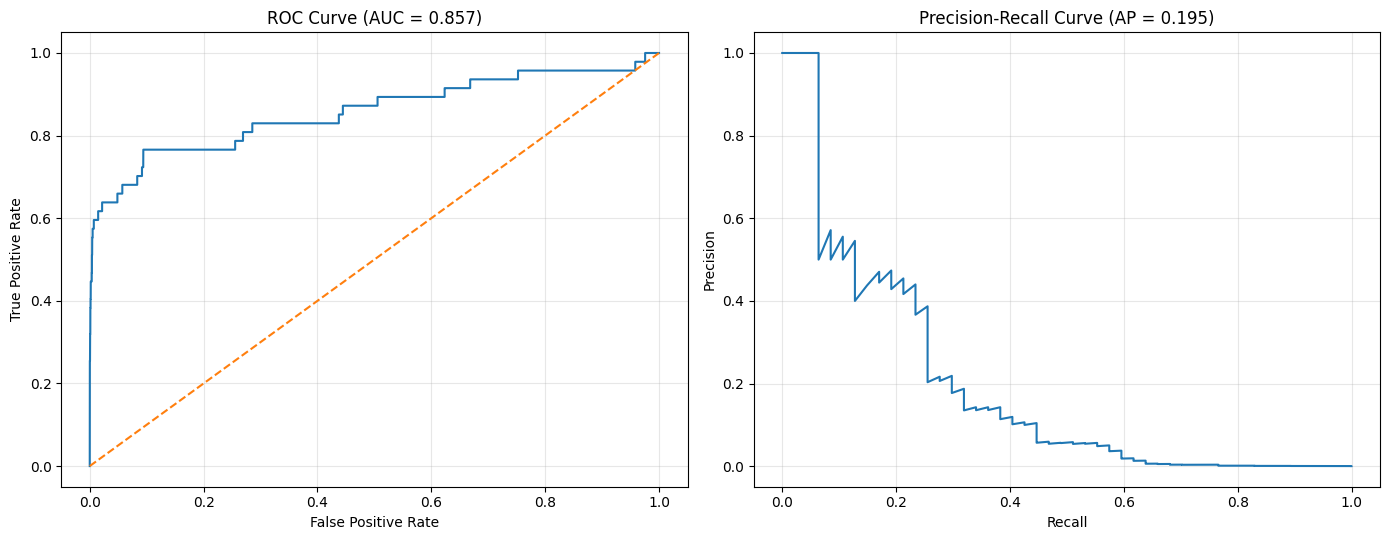

In [25]:
# ============================================================
# 22. ROC AND PRECISION-RECALL CURVES
# ============================================================

from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
)

fpr_curve, tpr_curve, _ = roc_curve(
    y_test,
    test_scores,
)

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    test_scores,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5)
)

axes[0].plot(
    fpr_curve,
    tpr_curve,
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

axes[0].set_xlabel(
    "False Positive Rate"
)

axes[0].set_ylabel(
    "True Positive Rate"
)

axes[0].set_title(
    f"ROC Curve (AUC = {roc_auc:.3f})"
)

axes[0].grid(
    alpha=0.3
)

axes[1].plot(
    recall_curve,
    precision_curve,
)

axes[1].set_xlabel(
    "Recall"
)

axes[1].set_ylabel(
    "Precision"
)

axes[1].set_title(
    f"Precision-Recall Curve (AP = {pr_auc:.3f})"
)

axes[1].grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# 23. TOP ANOMALIES
# ============================================================

top_positions = np.argsort(
    test_scores
)[-25:][::-1]

top_indices = X_test.index[
    top_positions
]

top = work.loc[
    top_indices
].copy()

top["anomaly_score"] = (
    test_scores[top_positions]
)

columns = [
    "step",
    "amount",
    "nameOrig",
    "nameDest",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "anomaly_score",
]

display(
    top[columns]
)

,step,amount,nameOrig,nameDest,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,anomaly_score
10395,7,5460002.91,C666654362,C1726301214,5460002.91,0.00,0.00,0.00,1,0.269736
196775,13,4022667.54,C735463888,C1548348754,4022667.54,0.00,0.00,0.00,1,0.254209
242982,14,2927005.15,C2081788795,C2138456206,2927005.15,0.00,0.00,0.00,1,0.243678
56757,9,1611762.94,C370806084,C356023140,7431.00,0.00,0.00,28309318.32,0,0.236067
346968,16,350752.29,C666793940,C2142478561,12290635.10,12641387.39,358203.62,25542331.57,0,0.224951
69245,9,2536199.21,C1946268494,C33712880,3563611.20,1027411.99,0.00,3378191.61,0,0.223025
248771,14,1832319.42,C439830884,C1133002328,1832319.42,0.00,0.00,0.00,1,0.215727
115900,11,13072.60,C1590416633,C327052591,884557.95,897630.55,52651.00,27410718.27,0,0.209674
196776,13,4022667.54,C79951219,C1499489682,4022667.54,0.00,80136.56,4057191.21,1,0.208276
396513,18,574961.32,C1421484581,C1854925027,10120778.36,10695739.68,41482697.12,40907735.80,0,0.205411


In [27]:
# ============================================================
# 24. FALSE NEGATIVES AND FALSE POSITIVES
# ============================================================

test_analysis = work.loc[
    X_test.index
].copy()

test_analysis["anomaly_score"] = (
    test_scores
)

test_analysis["predicted_fraud"] = (
    test_predictions
)

missed = (
    test_analysis[
        (test_analysis["isFraud"] == 1)
        & (test_analysis["predicted_fraud"] == 0)
    ]
    .sort_values(
        "anomaly_score",
        ascending=False,
    )
)

fp_rows = (
    test_analysis[
        (test_analysis["isFraud"] == 0)
        & (test_analysis["predicted_fraud"] == 1)
    ]
    .sort_values(
        "anomaly_score",
        ascending=False,
    )
)

print(
    "False negatives (missed fraud):",
    f"{len(missed):,}"
)

if len(missed):
    display(
        missed[
            [
                "step",
                "amount",
                "oldbalanceOrg",
                "newbalanceOrig",
                "oldbalanceDest",
                "newbalanceDest",
                "isFraud",
                "anomaly_score",
            ]
        ].head(25)
    )

print(
    "False positives:",
    f"{len(fp_rows):,}"
)

if len(fp_rows):
    display(
        fp_rows[
            [
                "step",
                "amount",
                "oldbalanceOrg",
                "newbalanceOrig",
                "oldbalanceDest",
                "newbalanceDest",
                "isFraud",
                "anomaly_score",
            ]
        ].head(25)
    )

False negatives (missed fraud): 32


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,anomaly_score
404428,18,307739.18,307739.18,0.00,0.00,0.00,1,0.101822
9284,7,262434.54,262434.54,0.00,0.00,0.00,1,0.099606
6583,6,216422.00,216422.00,0.00,0.00,0.00,1,0.098381
4775,4,86070.17,86070.17,0.00,0.00,0.00,1,0.090601
1869,1,25071.46,25071.46,0.00,0.00,0.00,1,0.083277
480463,19,161939.36,161939.36,0.00,0.00,0.00,1,0.081579
6702,6,17320.91,17320.91,0.00,0.00,0.00,1,0.056282
5852,6,26768.50,26768.50,0.00,0.00,0.00,1,0.053152
259844,14,65488.05,65488.05,0.00,0.00,0.00,1,0.052488
142087,11,12461.00,12461.00,0.00,0.00,0.00,1,0.048954


False positives: 86


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,anomaly_score
56757,9,1611762.94,7431.00,0.00,0.00,28309318.32,0,0.236067
346968,16,350752.29,12290635.10,12641387.39,358203.62,25542331.57,0,0.224951
69245,9,2536199.21,3563611.20,1027411.99,0.00,3378191.61,0,0.223025
115900,11,13072.60,884557.95,897630.55,52651.00,27410718.27,0,0.209674
396513,18,574961.32,10120778.36,10695739.68,41482697.12,40907735.80,0,0.205411
52155,9,1053311.47,2745833.08,3799144.55,16607810.14,22495526.04,0,0.201574
152116,12,1055638.69,19697366.08,20753004.77,11465238.76,10409600.07,0,0.198628
34292,8,2554999.36,2603747.66,48748.31,4369565.78,9374434.33,0,0.195807
403325,18,5572.78,34735.30,29162.52,19883.00,25088606.34,0,0.195738
19453,8,154184.05,0.00,0.00,305765.35,28783585.38,0,0.192222


,Metric,Value
0,Test transactions scored,100000.000000
1,Total inference time (sec),3.825240
2,Average latency (ms/transaction),0.038252
3,Observed throughput (transactions/sec),26142.151241


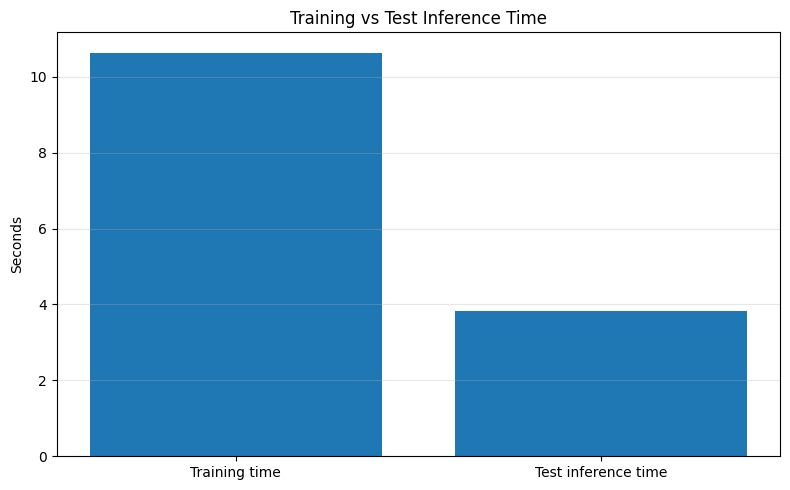

In [28]:
# ============================================================
# 25. INFERENCE PERFORMANCE
# ============================================================

test_rows = len(X_test)

latency_ms = (
    test_inference_time
    / test_rows
    * 1000
)

throughput = (
    test_rows
    / test_inference_time
)

runtime_table = pd.DataFrame({
    "Metric": [
        "Test transactions scored",
        "Total inference time (sec)",
        "Average latency (ms/transaction)",
        "Observed throughput (transactions/sec)",
    ],
    "Value": [
        test_rows,
        test_inference_time,
        latency_ms,
        throughput,
    ],
})

display(
    runtime_table
)

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    ["Training time", "Test inference time"],
    [final_training_time, test_inference_time],
)

plt.ylabel(
    "Seconds"
)

plt.title(
    "Training vs Test Inference Time"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 11. Deployment artifacts

The final stage saves the trained model and the information required to reproduce inference.

```text
models/
├── isolation_forest_final.pkl
├── isolation_forest_features.json
└── isolation_forest_config.json

results/
├── isolation_forest_final_results.json
├── isolation_forest_test_scores.csv
└── isolation_forest_search_results.csv
```

The feature list and configuration are kept separately because the streaming pipeline must reproduce the same feature contract and threshold.

In [29]:
# ============================================================
# 26. SAVE ARTIFACTS
# ============================================================

MODEL_PATH = (
    MODEL_DIR /
    "isolation_forest_final.pkl"
)

FEATURE_PATH = (
    MODEL_DIR /
    "isolation_forest_features.json"
)

CONFIG_PATH = (
    MODEL_DIR /
    "isolation_forest_config.json"
)

RESULT_PATH = (
    RESULT_DIR /
    "isolation_forest_final_results.json"
)

SCORES_PATH = (
    RESULT_DIR /
    "isolation_forest_test_scores.csv"
)

SEARCH_PATH = (
    RESULT_DIR /
    "isolation_forest_search_results.csv"
)

joblib.dump(
    final_model,
    MODEL_PATH,
)

with open(
    FEATURE_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        feature_columns,
        f,
        indent=4,
    )

config = {
    "model": "IsolationForest",
    "rows_loaded": int(len(df)),
    "n_features": int(X.shape[1]),
    "random_state": int(RANDOM_STATE),
    "n_estimators": int(
        selected_config["n_estimators"]
    ),
    "max_samples": selected_config["max_samples"],
    "max_features": selected_config["max_features"],
    "contamination": CONTAMINATION,
    "final_threshold": float(
        FINAL_THRESHOLD
    ),
    "high_recall_threshold": (
        None
        if high_recall_threshold is None
        else float(high_recall_threshold)
    ),
}

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        config,
        f,
        indent=4,
    )

score_export = pd.DataFrame({
    "row_index": X_test.index.to_numpy(),
    "actual_label": y_test.to_numpy(),
    "anomaly_score": test_scores,
    "predicted_label": test_predictions,
})

score_export.to_csv(
    SCORES_PATH,
    index=False,
)

search_results_df.to_csv(
    SEARCH_PATH,
    index=False,
)

results = {
    "model": "IsolationForest",
    "dataset": "PaySim",
    "rows_loaded": int(len(df)),
    "n_features": int(X.shape[1]),
    "train_rows": int(len(X_train)),
    "validation_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "normal_train_rows": int(len(X_train_normal)),
    "random_state": int(RANDOM_STATE),
    "n_estimators": int(
        selected_config["n_estimators"]
    ),
    "max_samples": selected_config["max_samples"],
    "max_features": selected_config["max_features"],
    "training_time_seconds": float(
        final_training_time
    ),
    "test_inference_time_seconds": float(
        test_inference_time
    ),
    "inference_latency_ms_per_transaction": float(
        latency_ms
    ),
    "throughput_transactions_per_second": float(
        throughput
    ),
    "threshold": float(
        FINAL_THRESHOLD
    ),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),
    "false_positive_rate": float(
        false_positive_rate
    ),
    "false_negative_rate": float(
        false_negative_rate
    ),
    "search_results_file": str(
        SEARCH_PATH
    ),
    "scores_file": str(
        SCORES_PATH
    ),
}

with open(
    RESULT_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        results,
        f,
        indent=4,
    )

for path in [
    MODEL_PATH,
    FEATURE_PATH,
    CONFIG_PATH,
    RESULT_PATH,
    SCORES_PATH,
    SEARCH_PATH,
]:
    print(
        "OK" if path.exists() else "MISSING",
        "-",
        path.resolve(),
    )

print(
    "\nExperiment artifacts saved."
)

OK - D:\Real-Time-Financial-Fraud-Detection-Pipeline-\models\isolation_forest_final.pkl
OK - D:\Real-Time-Financial-Fraud-Detection-Pipeline-\models\isolation_forest_features.json
OK - D:\Real-Time-Financial-Fraud-Detection-Pipeline-\models\isolation_forest_config.json
OK - D:\Real-Time-Financial-Fraud-Detection-Pipeline-\results\isolation_forest_final_results.json
OK - D:\Real-Time-Financial-Fraud-Detection-Pipeline-\results\isolation_forest_test_scores.csv
OK - D:\Real-Time-Financial-Fraud-Detection-Pipeline-\results\isolation_forest_search_results.csv

Experiment artifacts saved.
